In [61]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

In [62]:
#MENGUNGGAH/IMPORT DATASET
Data_Frame = pd.read_csv("data_order_pembelajaran.csv")
Data_Frame

,nomor order,nama,produk,category,quantitas,harga,order date,snipped,country
0,ORD-2026001,Siti Aminah,Wireless Mouse,Elektronik,2,300000,2026-02-05,J&T Express,Indonesia
1,ORD-2026002,Agus Setiawan,Bluetooth Earphone,Elektronik,4,150000,2026-01-08,J&T Express,Indonesia
2,ORD-2026003,Dewi Lestari,Topi Baseball,Pakaian,5,75000,2026-05-24,JNE Reguler,Indonesia
3,ORD-2026004,Agus Setiawan,Botol Minum Olahraga,Olahraga,4,120000,2026-07-27,J&T Express,Indonesia
4,ORD-2026005,Budi Santoso,Tali Skipping,Olahraga,3,60000,2026-02-25,SiCepat,Indonesia
5,ORD-2026006,Siti Aminah,Keyboard Mechanical,Elektronik,1,1200000,2026-08-05,SiCepat,Indonesia
6,ORD-2026007,Mega Utami,Blender Buah,Rumah Tangga,4,50000,2026-04-07,J&T Express,Indonesia
7,ORD-2026008,Agus Setiawan,Lampu LED 12W,Rumah Tangga,3,180000,2026-06-30,J&T Express,Indonesia
8,ORD-2026009,Ahmad Fauzi,Celana Chino,Pakaian,1,120000,2026-08-10,J&T Express,Indonesia
9,ORD-2026010,Rian Wijaya,Set Pisau Dapur,Rumah Tangga,3,180000,2026-04-05,SiCepat,Indonesia


In [74]:
#DATA WRANGLING

Data_Frame["order date"] = pd.to_datetime(Data_Frame["order date"]) #mengubah kolom order date menjadi tipe data datetime
Data_Frame["total sales"] = Data_Frame["quantitas"] * Data_Frame["harga"] #menentukan kolom total sales dgn mengalikan kolom quantitas dan harga
Data_Frame["bulan order"] = Data_Frame["order date"].dt.to_period("M") #membuat kolom bulan order dgn mengambil periode bulanan dari kolom order date
Data_Frame.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   nomor order  50 non-null     object        
 1   nama         50 non-null     object        
 2   produk       50 non-null     object        
 3   category     50 non-null     object        
 4   quantitas    50 non-null     int64         
 5   harga        50 non-null     int64         
 6   order date   50 non-null     datetime64[ns]
 7   snipped      50 non-null     object        
 8   country      50 non-null     object        
 9   total sales  50 non-null     int64         
 10  bulan order  50 non-null     period[M]     
dtypes: datetime64[ns](1), int64(3), object(6), period[M](1)
memory usage: 4.4+ KB


In [54]:
#AGGREGATION DATASET

#1. Menghitung Total Omset, Rata-rata Penjualan, dan Maksimum Penjualan
total_omset = np.sum(Data_Frame["total sales"])
rata_rata_transaksi = np.mean(Data_Frame["total sales"])
transaksi_terbesar = np.max(Data_Frame["total sales"])

total_omset, rata_rata_transaksi, transaksi_terbesar

(np.int64(79880000), np.float64(1597600.0), np.int64(30000000))

In [78]:
#2. Agregasi Penjualan per Bulan

rata_rata_penjualan = Data_Frame.groupby("bulan order")["total sales"].mean()
total_penjualan = Data_Frame.groupby("bulan order")["total sales"].sum().reset_index()
maksimum_penjualan = Data_Frame.groupby("bulan order")["total sales"].max()

rata_rata_penjualan.head(), total_penjualan.head(), maksimum_penjualan.head()

(bulan order
 2026-01     812500.0
 2026-02     695000.0
 2026-03     524000.0
 2026-04     447500.0
 2026-05    5941875.0
 Freq: M, Name: total sales, dtype: float64,
   bulan order  total sales
 0     2026-01      8125000
 1     2026-02      2780000
 2     2026-03      2620000
 3     2026-04      1790000
 4     2026-05     47535000,
 bulan order
 2026-01     2250000
 2026-02     1000000
 2026-03      750000
 2026-04     1000000
 2026-05    30000000
 Freq: M, Name: total sales, dtype: int64)

In [79]:
#3. Agregasi Penjualan per Kategori Produk (Di urutkan dari yang Terbesar to Terkecil)

rata_rata_penjualan_kategori = Data_Frame.groupby("category")["total sales"].sum().sort_values(ascending=False).reset_index()
total_penjualan["bulan order"] = total_penjualan["bulan order"].astype(str) #mengubah kolom bulan order menjadi tipe data string agar bisa di plot
rata_rata_penjualan_kategori

,category,total sales
0,Elektronik,58050000
1,Rumah Tangga,12230000
2,Olahraga,5175000
3,Pakaian,4425000


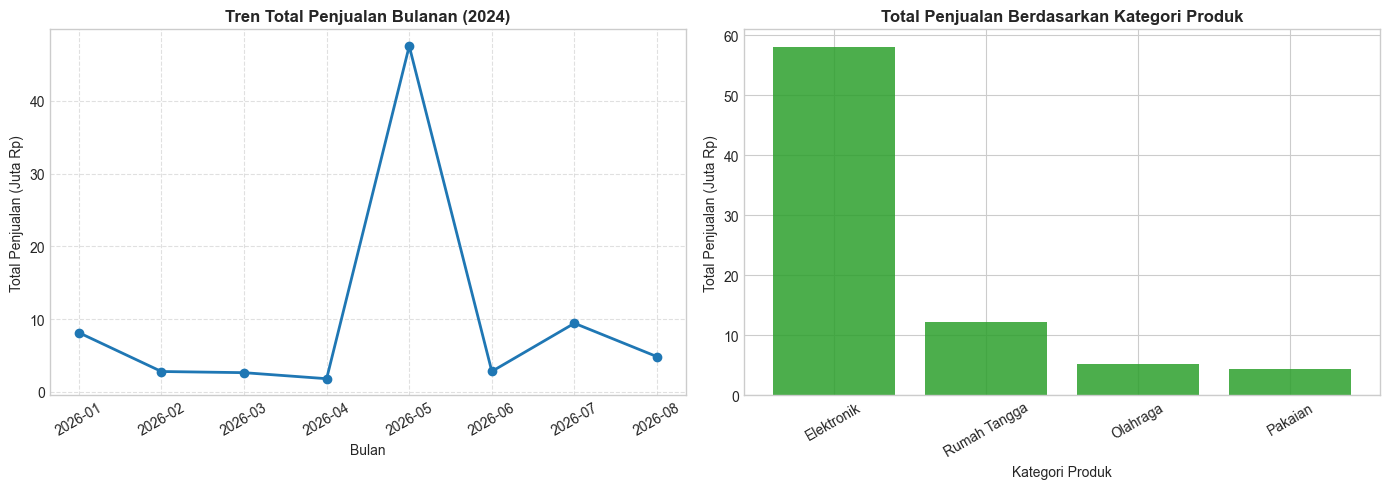

In [ ]:
# 1. Menentukan gaya/style grafik agar tampilan rapi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 2. Membuat kanvas tempat grafik (1 baris, 2 kolom grafik)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


#first pict: TREN PENJUALAN BULANAN (LINE CHART)

# Catatan: Nilai total_penjualan dibagi 1.000.000 agar sumbu Y lebih rapi (dalam Juta)
axes[0].plot(
    total_penjualan["bulan order"], 
    total_penjualan["total sales"] / 1e6, 
    marker='o', 
    color='#1f77b4', 
    linewidth=2
)
axes[0].set_title("Tren Total Penjualan Bulanan (2024)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Bulan", fontsize=10)
axes[0].set_ylabel("Total Penjualan (Juta Rp)", fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].tick_params(axis="x", rotation=30) # Memiringkan teks bulan agar tidak bertabrakan


#second pict: PENJUALAN BERDASARKAN KATEGORI PRODUK (BAR CHART)

axes[1].bar(
    rata_rata_penjualan_kategori["category"], 
    rata_rata_penjualan_kategori["total sales"] / 1e6, 
    color="#2ca02c", 
    alpha=0.85
)
axes[1].set_title("Total Penjualan Berdasarkan Kategori Produk", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Kategori Produk", fontsize=10)
axes[1].set_ylabel("Total Penjualan (Juta Rp)", fontsize=10)
axes[1].tick_params(axis="x", rotation=30)

# 3. Merapikan tata letak & menampilkan grafik
plt.tight_layout()
plt.savefig("grafik_penjualan.png", dpi=300)  # Menyimpan grafik sebagai file PNG dengan resolusi tinggi
plt.show()